In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import time
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Çalışma Ortamı: {device}")
if device.type == 'cuda':
    print(f"   Ekran Kartı: {torch.cuda.get_device_name(0)}")

DATA_DIR = r'C:\Users\user\Desktop\DerinProjem\garbage-dataset'

✅ Çalışma Ortamı: cuda
   Ekran Kartı: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Eğitim verisi için: Rastgele değiştirmeler yapıyoruz 
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), # Resmin %80'ine odaklan
    transforms.RandomHorizontalFlip(),      # Yatay çevir
    transforms.RandomRotation(15),          # Hafif döndür
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Işıkla oyna
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Test verisi için: Sadece boyutluyoruz (Orijinal kalsın)
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
classes = full_dataset.classes
print(f"📂 Sınıflar ({len(classes)} adet): {classes}")

📂 Sınıflar (10 adet): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [3]:
class_counts = {c: 0 for c in classes}
for _, label in full_dataset.samples:
    class_counts[classes[label]] += 1

print("\n📊 Veri Dağılımı (Hangi sınıftan kaç tane var?):")
print(class_counts)

# Ağırlık hesabı: Az örneği olana daha fazla ağırlık 
total_samples = sum(class_counts.values())
weights = [total_samples / class_counts[c] for c in classes]

# Bu ağırlıkları Loss fonksiyonuna vereceğiz
class_weights = torch.FloatTensor(weights).to(device)
print(f"\n⚖️ Hesaplanan Ağırlıklar: {[round(w, 2) for w in weights]}")


📊 Veri Dağılımı (Hangi sınıftan kaç tane var?):
{'battery': 944, 'biological': 997, 'cardboard': 1825, 'clothes': 5327, 'glass': 3061, 'metal': 1020, 'paper': 1680, 'plastic': 1984, 'shoes': 1977, 'trash': 947}

⚖️ Hesaplanan Ağırlıklar: [20.93, 19.82, 10.83, 3.71, 6.46, 19.37, 11.76, 9.96, 10.0, 20.87]


In [4]:
# Stratified Split 
targets = [s[1] for s in full_dataset.samples]

# %70 Eğitim, %30 Diğer
train_idx, temp_idx = train_test_split(
    np.arange(len(full_dataset)), test_size=0.3, stratify=targets, random_state=42
)

# Kalan %30'u -> %15 Validation, %15 Test 
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42
)

# Subsetleri oluşturuyoruz
train_ds = Subset(full_dataset, train_idx)
# Val ve Test için 'temiz' transform kullanıyoruz (Augmentation yok)
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), val_idx)
test_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=test_tfms), test_idx)

# DataLoader
BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ Veri Hazır! Eğitim: {len(train_ds)}, Doğrulama: {len(val_ds)}, Test: {len(test_ds)}")


✅ Veri Hazır! Eğitim: 13833, Doğrulama: 2964, Test: 2965


In [5]:
def get_alexnet_model(num_classes):
    print("\n🛠️ AlexNet Modeli İndiriliyor...")
    model = models.alexnet(pretrained=True)
    
    # Feature Extraction (Özellik Çıkarımı) katmanlarını dondur
    # Çünkü bu katmanlar zaten milyonlarca resimle eğitildi, işi biliyorlar.
    for param in model.features.parameters():
        param.requires_grad = False
    
    # Classifier (Sınıflandırıcı) Kısmı:
    # AlexNet'in son katmanı (indeks 6) bir Linear katmandır.
    # Bunu kendi sınıfımıza göre değiştiriyoruz.
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, num_classes)
    
    return model.to(device)

model = get_alexnet_model(len(classes))

# Loss ve Optimizer
# Hesapladığımız ağırlıkları (class_weights) buraya veriyoruz!
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Sadece son kısmı (classifier) eğiteceğiz, öğrenme hızını düşük tutuyoruz.
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)


🛠️ AlexNet Modeli İndiriliyor...


C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\pytorch_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
def train_model(model, train_loader, val_loader, epochs=15):
    start_time = time.time()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    print(f"\n🚀 Eğitim Başlıyor... ({epochs} Epoch sürecek)")
    print("-" * 60)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # --- SHAPE DEBUGGING ---
        if epoch == 0:
            # İlk batch'i manuel çekip kontrol edelim
            inputs_sample, labels_sample = next(iter(train_loader))
            print(f"🔍 [DEBUG] Input Shape: {inputs_sample.shape} (32 resim, 3 kanal RGB, 224x224)")
            print(f"🔍 [DEBUG] Label Shape: {labels_sample.shape} (32 etiket)")
            print("-" * 30)

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()         # Önceki türevleri temizle
            outputs = model(inputs)       # Tahmin yap
            loss = criterion(outputs, labels) # Hatayı hesapla
            loss.backward()               # Geriye yayılım (Backprop)
            optimizer.step()              # Ağırlıkları güncelle
            
            running_loss += loss.item() * inputs.size(0)

        # Validation (Doğrulama) Kısmı
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

        # En iyi modeli hafızada tut
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    print(f'\n✨ Eğitim Tamamlandı! Süre: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'🏆 En İyi Val Accuracy: {best_acc:.4f}')
    
    # En iyi ağırlıkları modele yükle
    model.load_state_dict(best_wts)
    return model, history

In [7]:
# Eğitimi başlatıyoruz
trained_alexnet, history = train_model(model, train_dl, val_dl, epochs=15)


🚀 Eğitim Başlıyor... (15 Epoch sürecek)
------------------------------------------------------------
🔍 [DEBUG] Input Shape: torch.Size([32, 3, 224, 224]) (32 resim, 3 kanal RGB, 224x224)
🔍 [DEBUG] Label Shape: torch.Size([32]) (32 etiket)
------------------------------
Epoch 1/15 | Train Loss: 0.7426 | Val Loss: 0.4295 | Val Acc: 0.8677
Epoch 2/15 | Train Loss: 0.4515 | Val Loss: 0.4238 | Val Acc: 0.8907
Epoch 3/15 | Train Loss: 0.3618 | Val Loss: 0.3597 | Val Acc: 0.8968
Epoch 4/15 | Train Loss: 0.2992 | Val Loss: 0.3218 | Val Acc: 0.9086
Epoch 5/15 | Train Loss: 0.2586 | Val Loss: 0.3339 | Val Acc: 0.9096
Epoch 6/15 | Train Loss: 0.2299 | Val Loss: 0.3013 | Val Acc: 0.9214
Epoch 7/15 | Train Loss: 0.2183 | Val Loss: 0.3104 | Val Acc: 0.9177
Epoch 8/15 | Train Loss: 0.1895 | Val Loss: 0.2872 | Val Acc: 0.9271
Epoch 9/15 | Train Loss: 0.1712 | Val Loss: 0.3071 | Val Acc: 0.9248
Epoch 10/15 | Train Loss: 0.1531 | Val Loss: 0.3336 | Val Acc: 0.9177
Epoch 11/15 | Train Loss: 0.1653 | Val


📈 Grafikler çiziliyor...


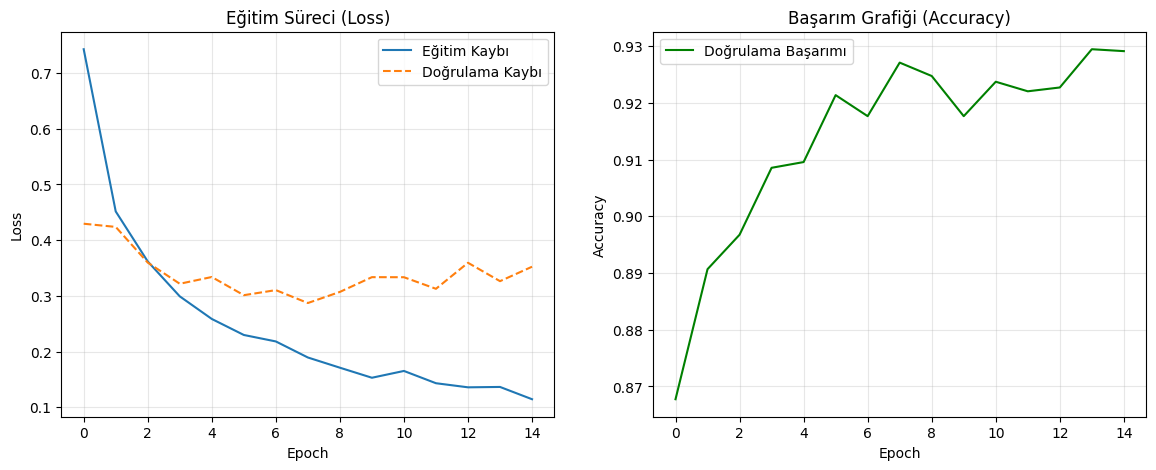

In [8]:
def plot_history(history):
    epochs_range = range(len(history['train_loss']))
    
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Kayıp (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Eğitim Kaybı')
    plt.plot(epochs_range, history['val_loss'], label='Doğrulama Kaybı', linestyle='--')
    plt.title('Eğitim Süreci (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Grafik: Başarım (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], label='Doğrulama Başarımı', color='green')
    plt.title('Başarım Grafiği (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

print("\n📈 Grafikler çiziliyor...")
plot_history(history)

In [9]:
def evaluate_detailed(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("\n🧪 Test Seti üzerinde analiz yapılıyor...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

  
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    
    results = []
    for cls in class_names:
        d = report_dict[cls]
        results.append({
            "Sınıf": cls,
            "Accuracy": d['recall'], 
            "Precision": d['precision'],
            "Recall": d['recall'],
            "F1-Score": d['f1-score']
        })
    
    df = pd.DataFrame(results)
   
    df = df[["Sınıf", "Accuracy", "Precision", "Recall", "F1-Score"]]
    
    print("\n" + "="*50)
    print("📊 ALEXNET - DETAYLI PERFORMANS TABLOSU")
    print("="*50)
    print(df.round(4).to_string(index=False))
    
   
    df.to_csv('alexnet_detailed_results.csv', index=False)
    print("\n💾 Sonuçlar 'alexnet_detailed_results.csv' dosyasına kaydedildi.")
    
    return all_labels, all_preds

y_true, y_pred = evaluate_detailed(trained_alexnet, test_dl, classes)


🧪 Test Seti üzerinde analiz yapılıyor...

📊 ALEXNET - DETAYLI PERFORMANS TABLOSU
     Sınıf  Accuracy  Precision  Recall  F1-Score
   battery    0.9504     0.9178  0.9504    0.9338
biological    0.9530     0.9342  0.9530    0.9435
 cardboard    0.9161     0.9228  0.9161    0.9194
   clothes    0.9712     0.9810  0.9712    0.9761
     glass    0.8913     0.9213  0.8913    0.9061
     metal    0.9020     0.7624  0.9020    0.8263
     paper    0.8651     0.8617  0.8651    0.8634
   plastic    0.8591     0.8767  0.8591    0.8678
     shoes    0.8855     0.9359  0.8855    0.9100
     trash    0.8592     0.8026  0.8592    0.8299

💾 Sonuçlar 'alexnet_detailed_results.csv' dosyasına kaydedildi.



📷 Örnek Tahminler Gösteriliyor...


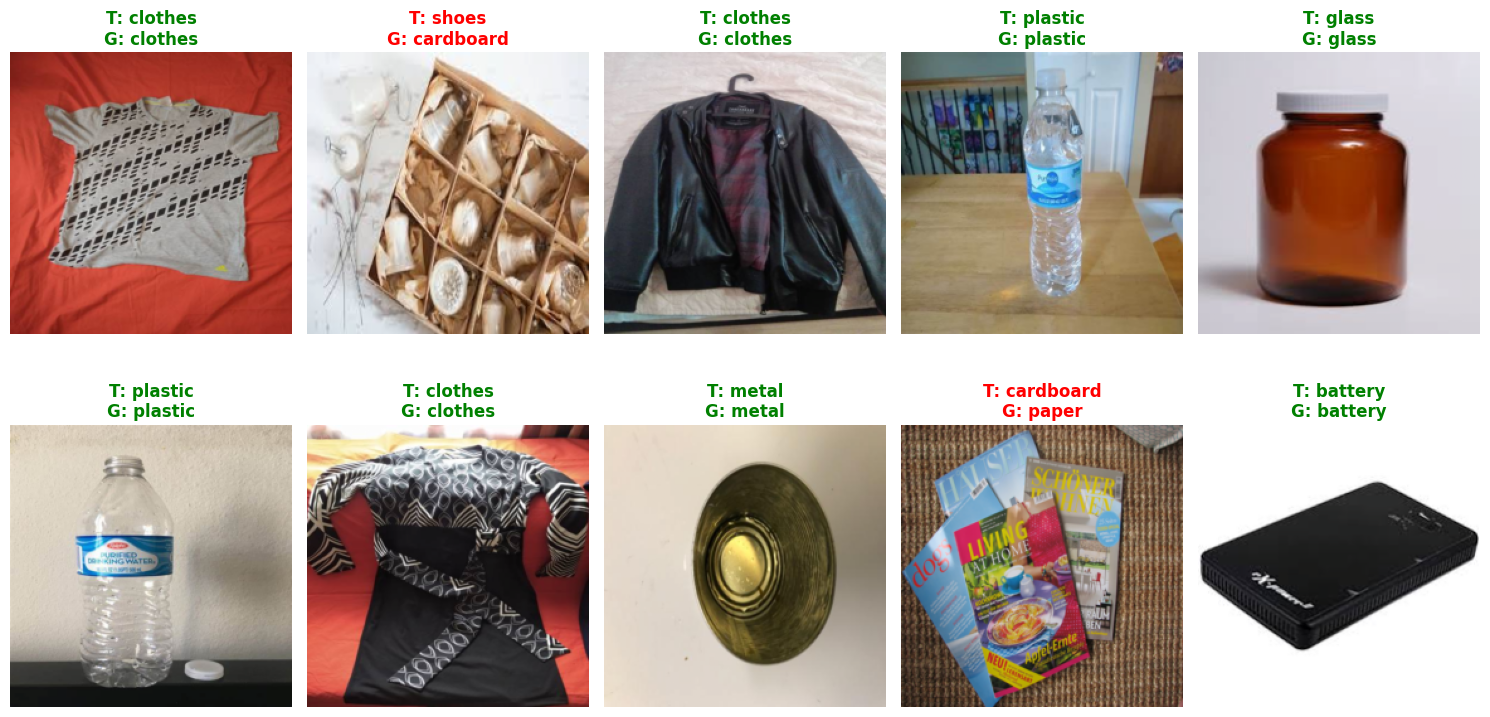

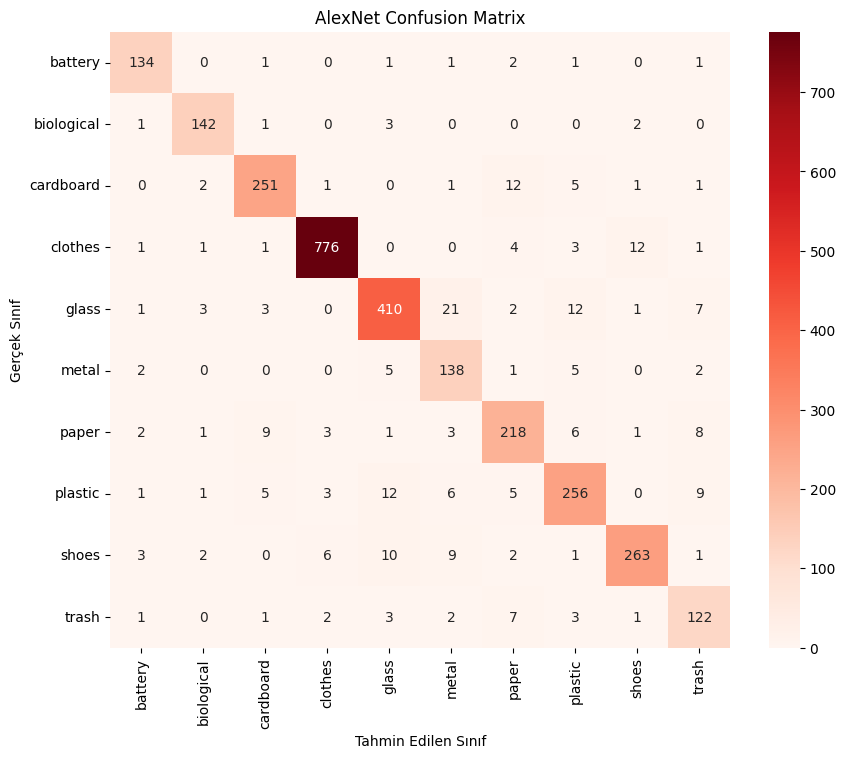

In [10]:
def visualize_predictions(model, loader, class_names, num_images=10):
    model.eval()
    images_shown = 0
    
    # Resmi eski haline (normal görüntüye) çevirmek için
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    plt.figure(figsize=(15, 8))
    print("\n📷 Örnek Tahminler Gösteriliyor...")

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                
                ax = plt.subplot(2, 5, images_shown + 1)
                ax.axis('off')
                
               
                img = inputs.cpu().data[j]
                img = inv_normalize(img)
                img = np.transpose(img.numpy(), (1, 2, 0))
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                
                
                pred_label = class_names[preds[j]]
                true_label = class_names[labels[j]]
                color = 'green' if pred_label == true_label else 'red'
                
                ax.set_title(f"T: {pred_label}\nG: {true_label}", color=color, fontweight='bold')
                images_shown += 1
            
            if images_shown >= num_images:
                break
    plt.tight_layout()
    plt.show()

visualize_predictions(trained_alexnet, test_dl, classes)

# ---(Confusion Matrix) ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('AlexNet Confusion Matrix')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

In [12]:
def evaluate_fixed(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("\n🧪 Test Seti Analiz Ediliyor...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

  
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
   
    acc = report_dict['accuracy']
    macro_f1 = report_dict['macro avg']['f1-score']
    weighted_f1 = report_dict['weighted avg']['f1-score']
    
    print("\n" + "="*40)
    print("🌍 MODEL GENEL PERFORMANSI")
    print("="*40)
    print(f"Genel Doğruluk (Accuracy) : %{acc*100:.2f}")
    print(f"Ortalama F1-Score         : %{macro_f1*100:.2f}")
    print(f"Ağırlıklı F1-Score        : %{weighted_f1*100:.2f}")
    print("="*40)
    
    
    results = []
    for cls in class_names:
        d = report_dict[cls]
        results.append({
            "Sınıf": cls,
            "Accuracy": d['recall'], # Not: Literatürde sınıf bazlı accuracy genelde Recall'dur.
            "Precision": d['precision'],
            "Recall": d['recall'],
            "F1-Score": d['f1-score']
        })
    
    df = pd.DataFrame(results)
    
    df = df[["Sınıf", "Accuracy", "Precision", "Recall", "F1-Score"]]
    
    print("\n📊 SINIF BAZLI DETAYLI TABLO")
    print("-" * 60)
    print(df.round(4).to_string(index=False))
    print("-" * 60)
    
    # CSV Kaydet
    df.to_csv('alexnet_final_report.csv', index=False)
    print("\n💾 Tablo 'alexnet_final_report.csv' olarak kaydedildi.")
    
    return all_labels, all_preds


y_true, y_pred = evaluate_fixed(trained_alexnet, test_dl, classes)


🧪 Test Seti Analiz Ediliyor...

🌍 MODEL GENEL PERFORMANSI
Genel Doğruluk (Accuracy) : %91.40
Ortalama F1-Score         : %89.76
Ağırlıklı F1-Score        : %91.45

📊 SINIF BAZLI DETAYLI TABLO
------------------------------------------------------------
     Sınıf  Accuracy  Precision  Recall  F1-Score
   battery    0.9504     0.9178  0.9504    0.9338
biological    0.9530     0.9342  0.9530    0.9435
 cardboard    0.9161     0.9228  0.9161    0.9194
   clothes    0.9712     0.9810  0.9712    0.9761
     glass    0.8913     0.9213  0.8913    0.9061
     metal    0.9020     0.7624  0.9020    0.8263
     paper    0.8651     0.8617  0.8651    0.8634
   plastic    0.8591     0.8767  0.8591    0.8678
     shoes    0.8855     0.9359  0.8855    0.9100
     trash    0.8592     0.8026  0.8592    0.8299
------------------------------------------------------------

💾 Tablo 'alexnet_final_report.csv' olarak kaydedildi.



🚀 AlexNet (Fine-Tuned) İçin Tüm Grafikler Hazırlanıyor... (Biraz sürebilir)


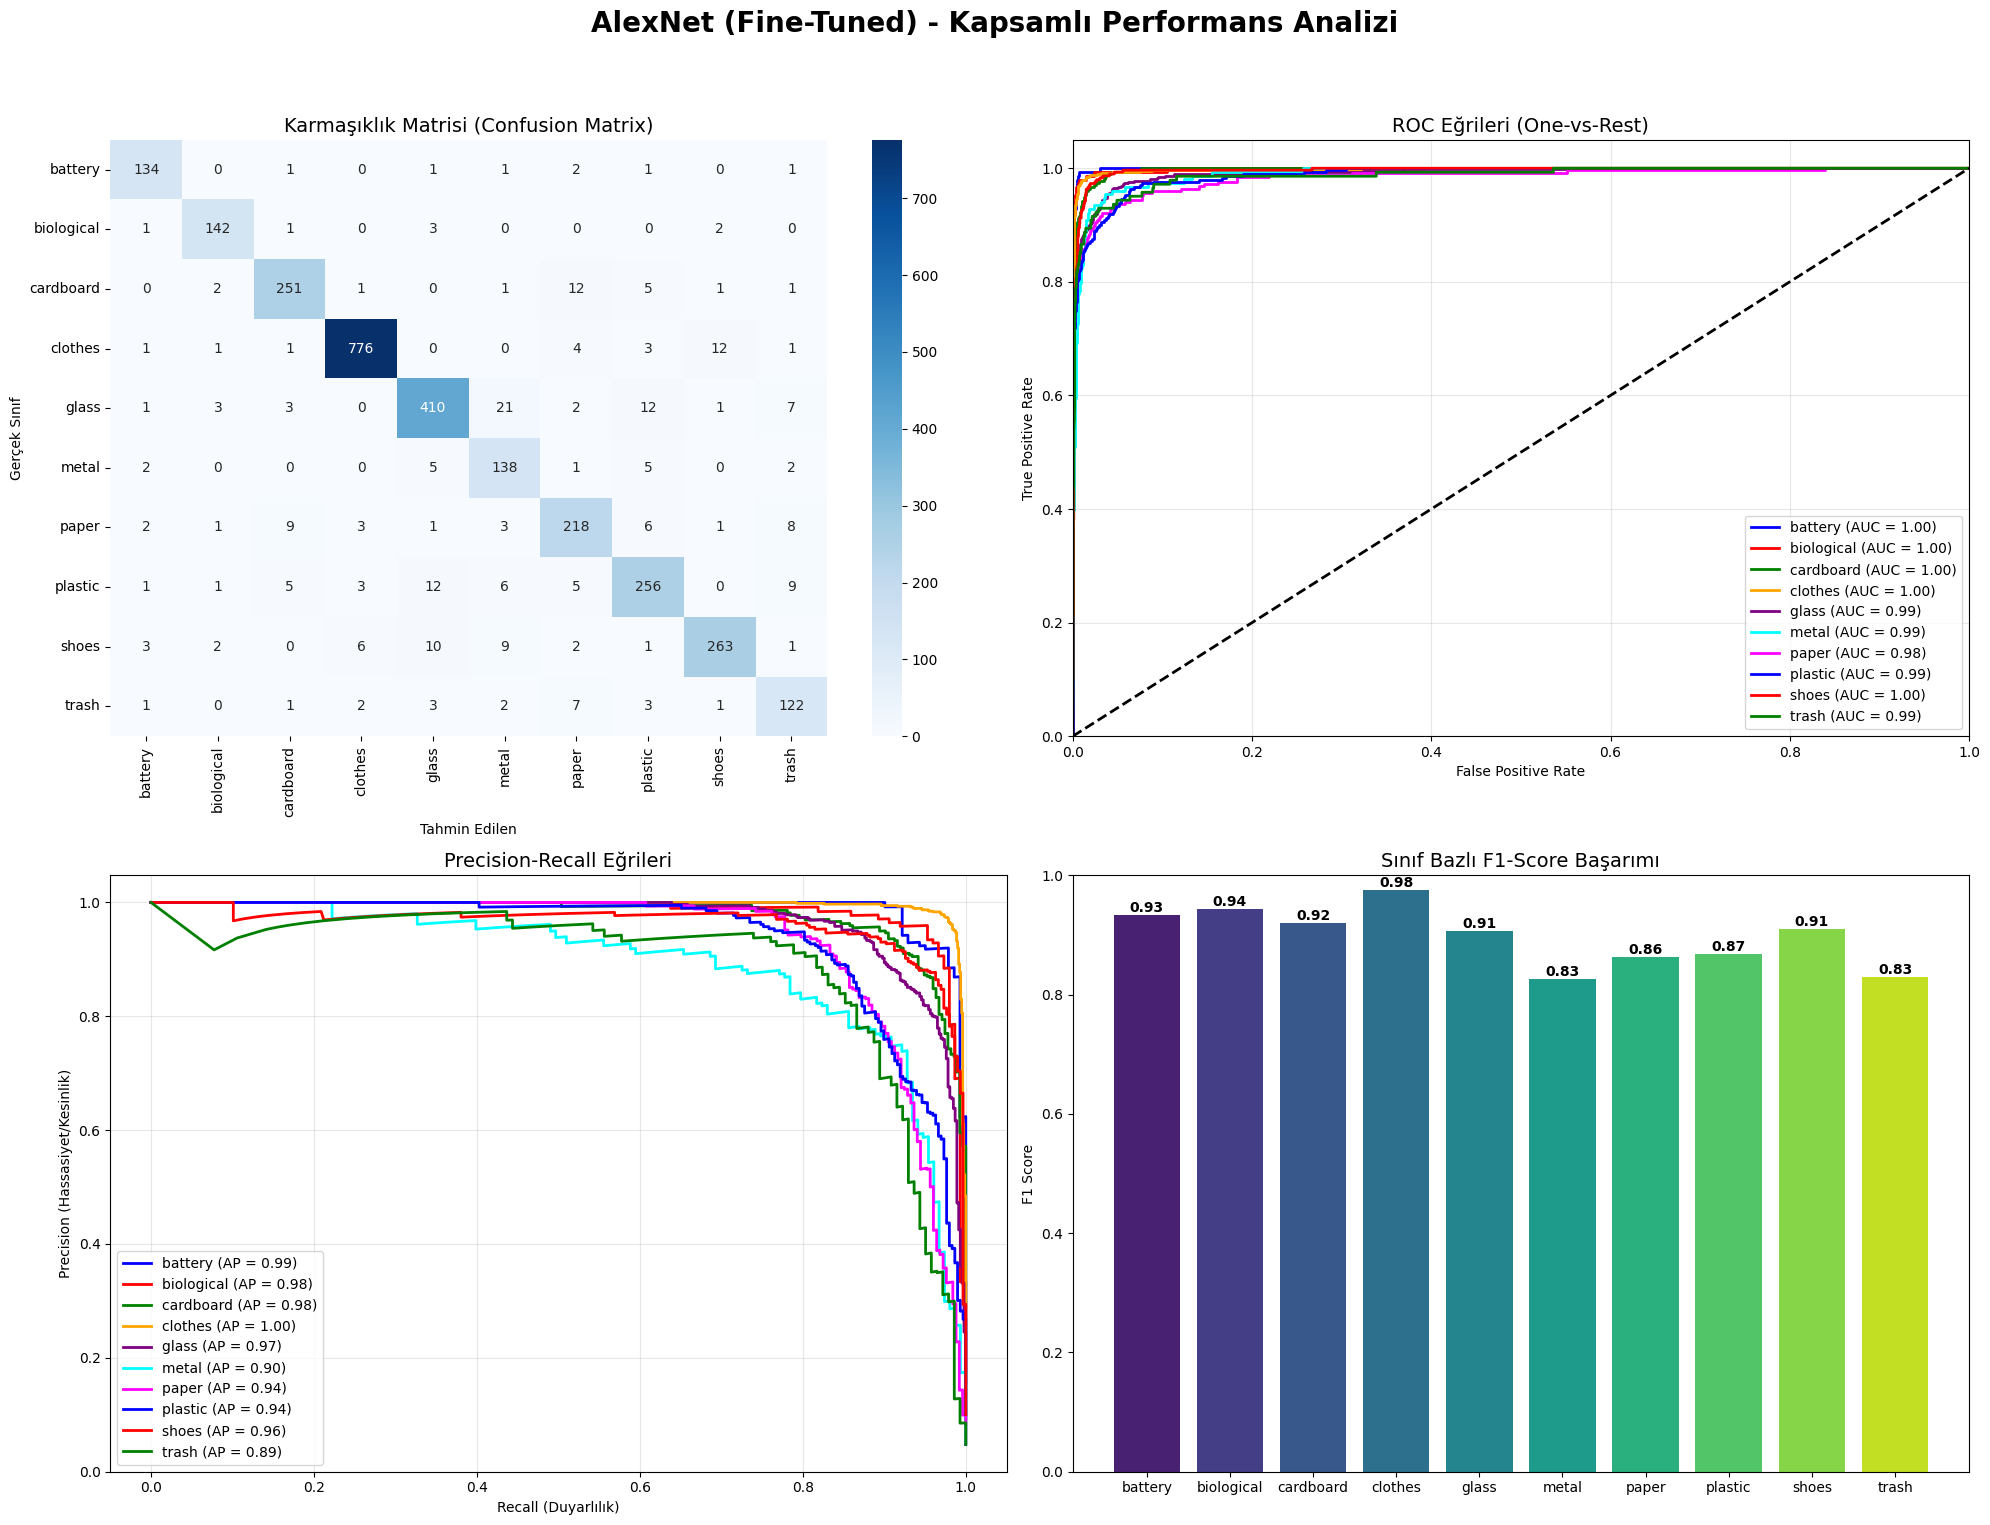

In [13]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, f1_score
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import pandas as pd

def plot_all_metrics(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon tek seferde Confusion Matrix, ROC, Precision-Recall ve F1 Skorlarını çizer.
    Tam teşekküllü bir raporlama aracıdır.
    """
    model.eval()
    
    y_true = []
    y_scores = [] # Olasılıklar (Softmax çıktıları)
    y_pred = []   # Kesin tahminler (0, 1, 2...)
    
    print(f"\n🚀 {model_name} İçin Tüm Grafikler Hazırlanıyor... (Biraz sürebilir)")
    
   
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Olasılıkları al (ROC ve PR için şart)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Tahminleri al (Confusion Matrix için şart)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    y_pred = np.array(y_pred)
    
    # Veriyi Binarize Et (One-Hot Encoding - ROC/PR için gerekli)
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    plt.suptitle(f"{model_name} - Kapsamlı Performans Analizi", fontsize=20, fontweight='bold')
    
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    # ---------------------------------------------------------
    # 1. GRAFİK: CONFUSION MATRIX (Karmaşıklık Matrisi)
    # ---------------------------------------------------------
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=14)
    axes[0, 0].set_xlabel('Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek Sınıf')

    # ---------------------------------------------------------
    # 2. GRAFİK: ROC CURVES (Alıcı İşletim Karakteristiği)
    # ---------------------------------------------------------
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, color=color, lw=2,
                        label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
    axes[0, 1].set_xlim([0.0, 1.0])
    axes[0, 1].set_ylim([0.0, 1.05])
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=14)
    axes[0, 1].legend(loc="lower right")
    axes[0, 1].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 3. GRAFİK: PRECISION-RECALL CURVES (Hassasiyet-Duyarlılık)
    # ---------------------------------------------------------
   
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    for i, color in zip(range(n_classes), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        avg_precision = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        axes[1, 0].plot(recall, precision, color=color, lw=2,
                        label=f'{class_names[i]} (AP = {avg_precision:.2f})')
    
    axes[1, 0].set_xlabel('Recall (Duyarlılık)')
    axes[1, 0].set_ylabel('Precision (Hassasiyet/Kesinlik)')
    axes[1, 0].set_title('Precision-Recall Eğrileri', fontsize=14)
    axes[1, 0].legend(loc="lower left")
    axes[1, 0].grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 4. GRAFİK: SINIF BAZLI F1 SKORLARI (Bar Chart)
    # ---------------------------------------------------------
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
  
    palette = sns.color_palette("viridis", len(class_names))
    bars = axes[1, 1].bar(class_names, f1_scores, color=palette)
    
    axes[1, 1].set_ylim([0, 1.0])
    axes[1, 1].set_title('Sınıf Bazlı F1-Score Başarımı', fontsize=14)
    axes[1, 1].set_ylabel('F1 Score')
    
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Başlık için yer aç
    plt.show()



if 'trained_alexnet' in locals():
    plot_all_metrics(trained_alexnet, test_dl, classes, model_name="AlexNet (Fine-Tuned)")


In [16]:
from sklearn.metrics import classification_report
import pandas as pd
import torch

def generate_full_report(model, loader, class_names, model_name="AlexNet"):
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"\n📊 {model_name} İçin Tam Kapsamlı Rapor Hazırlanıyor...")
    
    # 1. Tahminleri Topla
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 2. Scikit-learn Raporunu 'Dictionary' olarak al
    report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    # -------------------------------------------------------
    # TABLO 1: GENEL PERFORMANS (General Metrics)
    # -------------------------------------------------------
    # Accuracy tek bir değerdir, onu satır yapalım.
    # Macro ve Weighted Avg ise Precision/Recall/F1 içerir.
    
    general_data = []
    
    # Satır 1: Genel Doğruluk (Accuracy) 
    general_data.append({
        "Metrik Türü": "Genel Doğruluk (Accuracy)",
        "Precision": "-", 
        "Recall": "-",
        "F1-Score": round(report_dict['accuracy'], 4)
    })
    
    # Satır 2: Macro Average (Aritmetik Ortalama)
    general_data.append({
        "Metrik Türü": "Macro Avg (Ortalama)",
        "Precision": round(report_dict['macro avg']['precision'], 4),
        "Recall": round(report_dict['macro avg']['recall'], 4),
        "F1-Score": round(report_dict['macro avg']['f1-score'], 4)
    })
    
    # Satır 3: Weighted Average (Ağırlıklı Ortalama)
    general_data.append({
        "Metrik Türü": "Weighted Avg (Ağırlıklı)",
        "Precision": round(report_dict['weighted avg']['precision'], 4),
        "Recall": round(report_dict['weighted avg']['recall'], 4),
        "F1-Score": round(report_dict['weighted avg']['f1-score'], 4)
    })
    
    df_general = pd.DataFrame(general_data)
    
    print("\n" + "="*60)
    print(f"🌍 {model_name} - GENEL PERFORMANS TABLOSU")
    print("="*60)
    print(df_general.to_string(index=False))
    
    # -------------------------------------------------------
    # TABLO 2: SINIF BAZLI PERFORMANS (Class-wise Metrics)
    # -------------------------------------------------------
    class_data = []
    for cls in class_names:
        metrics = report_dict[cls]
        class_data.append({
            "Sınıf": cls,
            "Accuracy (Recall)": round(metrics['recall'], 4), # İstediğin: Class Accuracy = Recall
            "Precision": round(metrics['precision'], 4),
            "Recall": round(metrics['recall'], 4),
            "F1-Score": round(metrics['f1-score'], 4)
        })
        
    df_class = pd.DataFrame(class_data)
    
    print("\n" + "-"*60)
    print(f"🔍 {model_name} - SINIF BAZLI DETAYLI TABLO")
    print("-"*60)
    print(df_class.to_string(index=False))
    print("="*60)

   
    filename = f"{model_name}_Full_Report.csv"
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(f"{model_name} GENEL METRIKLER\n")
        df_general.to_csv(f, index=False)
        f.write("\n") # Boşluk bırak
        f.write(f"{model_name} SINIF BAZLI METRIKLER\n")
        df_class.to_csv(f, index=False)
        
    print(f"\n💾 Rapor Kaydedildi: {filename}")
    
    return all_labels, all_preds

In [19]:
import torch
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


model = trained_alexnet 
model.eval()

all_preds = []
all_labels = []

print("⏳ AlexNet Genel Performansı Hesaplanıyor...")

with torch.no_grad():
    for inputs, labels in test_dl:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrikleri Hesapla
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

# Tabloyu Oluştur
df_alex = pd.DataFrame([{
    "Model": "AlexNet",
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1-Score": round(f1, 4)
}])

print("\n" + "="*50)
print("📊 ALEXNET GENEL PERFORMANS TABLOSU")
print("="*50)
print(df_alex.to_string(index=False))
print("="*50)

⏳ AlexNet Genel Performansı Hesaplanıyor...

📊 ALEXNET GENEL PERFORMANS TABLOSU
  Model  Accuracy  Precision  Recall  F1-Score
AlexNet     0.914     0.9161   0.914    0.9145



🚀 ALEXNET ANALİZİ BAŞLATILIYOR... Lütfen bekleyin.

🌍 ALEXNET - GENEL PERFORMANS TABLOSU
  Model  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
AlexNet     0.914                0.9161              0.914               0.9145

--------------------------------------------------
🔍 ALEXNET - SINIF DETAYLARI
--------------------------------------------------
     Sınıf  Accuracy (Recall)  Precision  Recall  F1-Score
   battery             0.9504     0.9178  0.9504    0.9338
biological             0.9530     0.9342  0.9530    0.9435
 cardboard             0.9161     0.9228  0.9161    0.9194
   clothes             0.9712     0.9810  0.9712    0.9761
     glass             0.8913     0.9213  0.8913    0.9061
     metal             0.9020     0.7624  0.9020    0.8263
     paper             0.8651     0.8617  0.8651    0.8634
   plastic             0.8591     0.8767  0.8591    0.8678
     shoes             0.8855     0.9359  0.8855    0.9100
     trash             0.8592

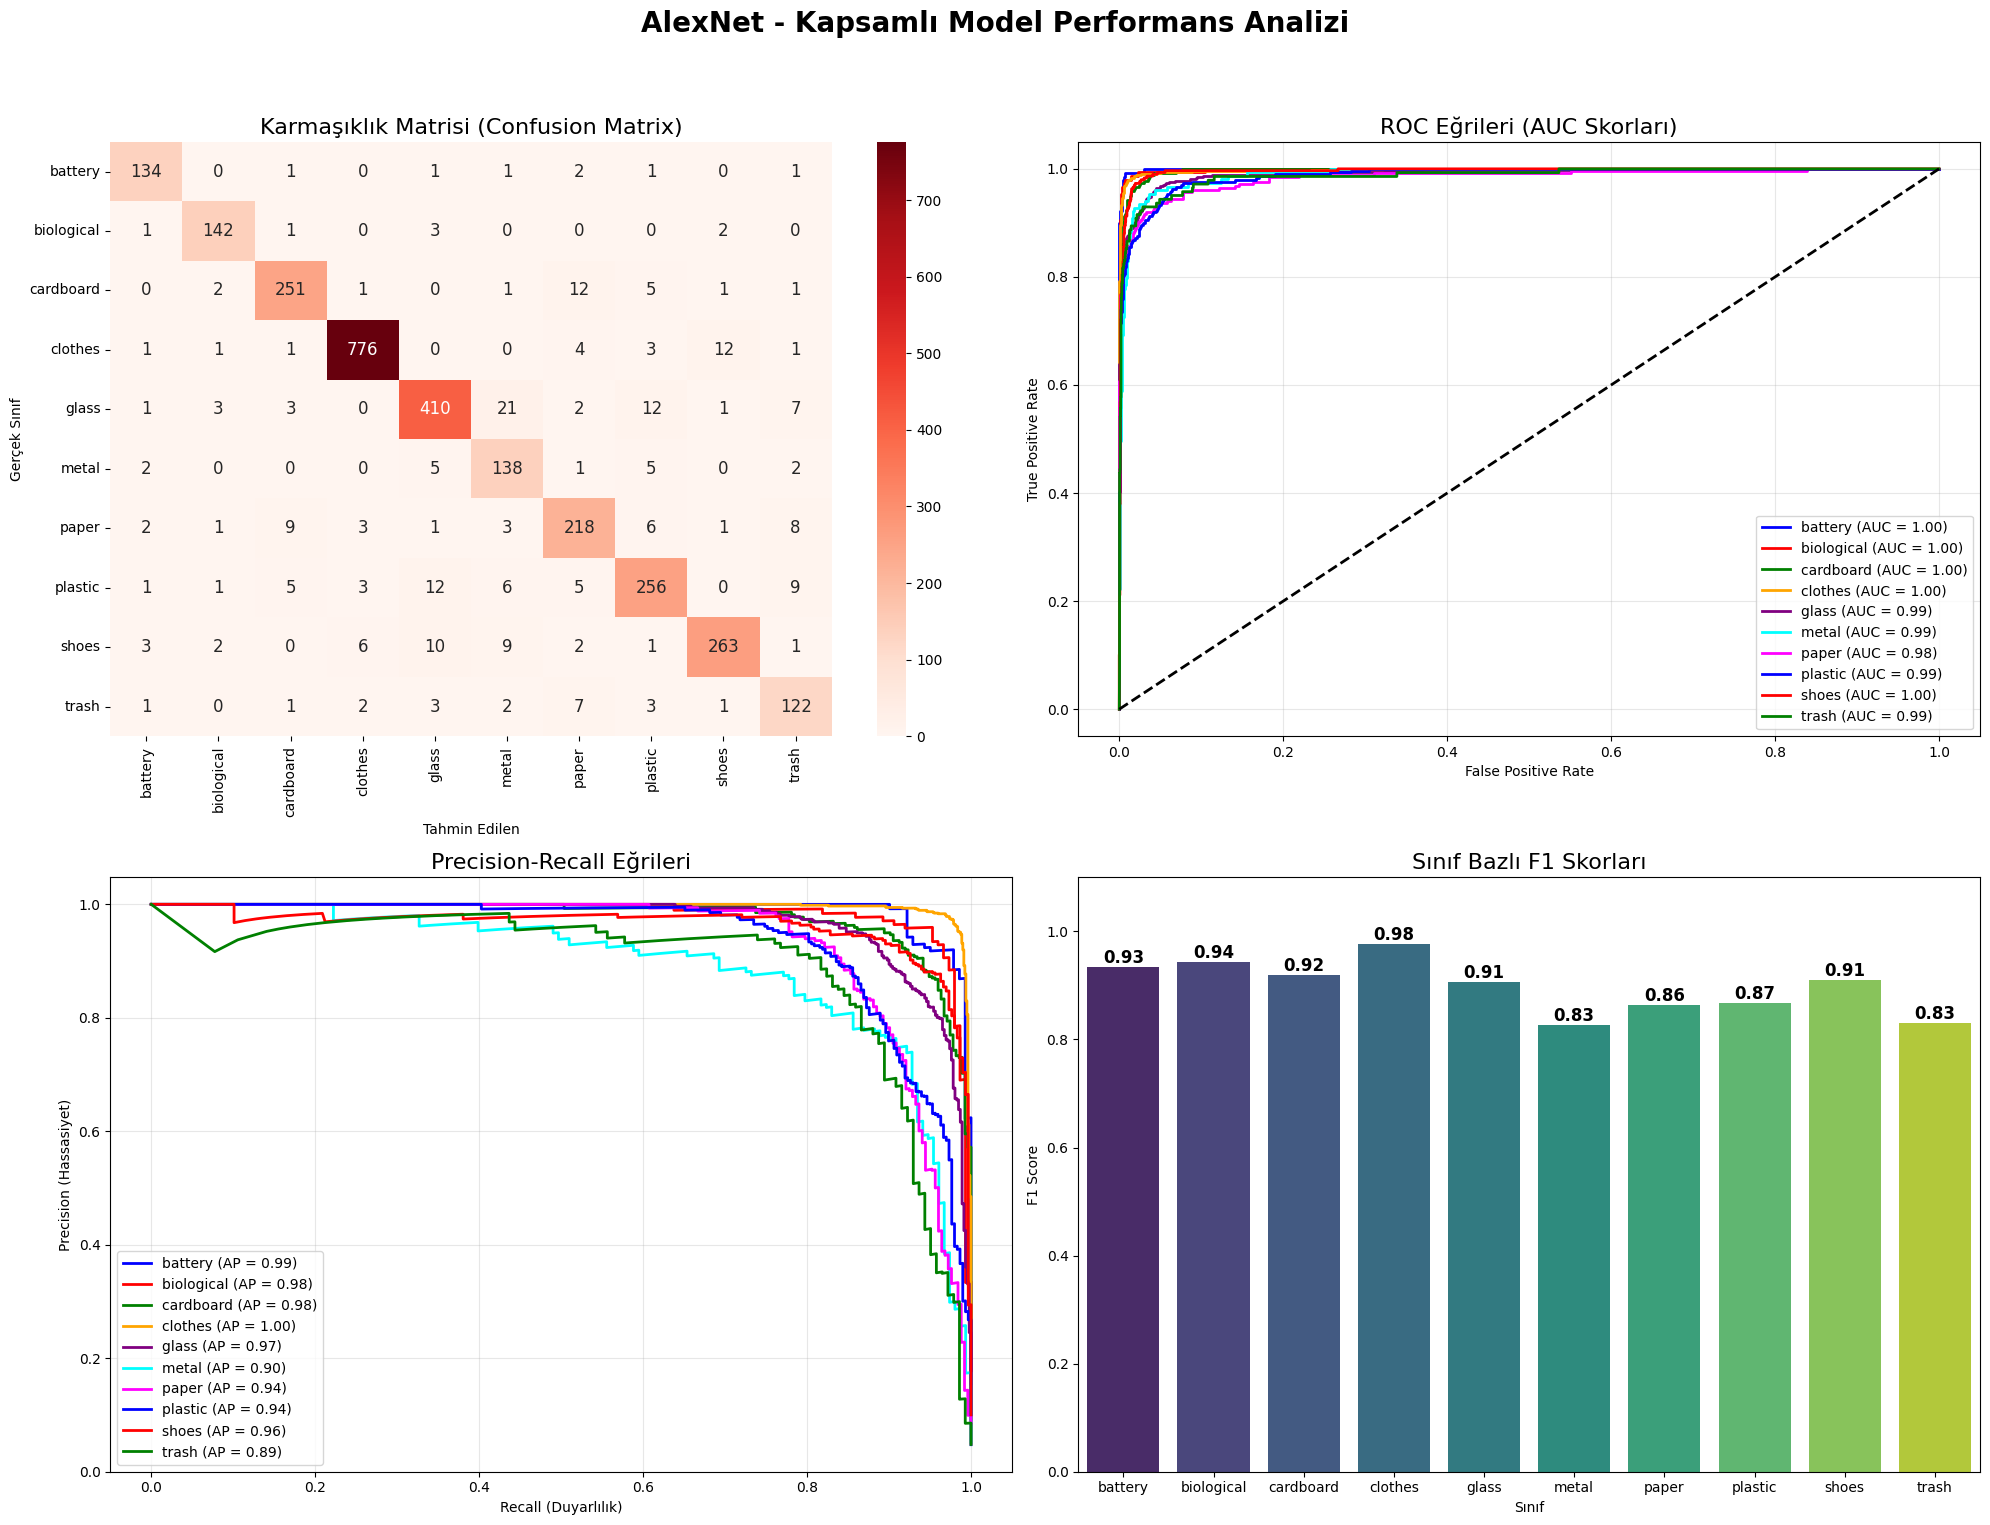

✅ Görselleştirme Tamamlandı! 'AlexNet_Tum_Grafikler.png' kaydedildi.


In [26]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc, 
                             precision_recall_curve, average_precision_score, accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import warnings

# Gereksiz uyarıları kapatıyoruz
warnings.filterwarnings('ignore')

def analyze_alexnet(model, loader, class_names):
    """
    AlexNet modeli için özel, hatasız görselleştirme ve raporlama fonksiyonu.
    """
    print("\n🚀 ALEXNET ANALİZİ BAŞLATILIYOR... Lütfen bekleyin.")
    
    # 1. Cihazı Otomatik Bul (Hata riskini sıfırlar)
    try:
        device = next(model.parameters()).device
    except:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.to(device)
    model.eval()
    
    y_true = []
    y_pred = []
    y_scores = [] # Olasılıklar (Grafikler için şart)
    
    # 2. Verileri Topla
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            
            # Olasılıkları hesapla (Softmax)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Tahmin edilen sınıfı al
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_scores.extend(probs.cpu().numpy())

    # Numpy formatına çevir
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    n_classes = len(class_names)
    
   
    
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    
    df_general = pd.DataFrame([{
        "Model": "AlexNet",
        "Accuracy": round(report['accuracy'], 4),
        "Precision (Weighted)": round(report['weighted avg']['precision'], 4),
        "Recall (Weighted)": round(report['weighted avg']['recall'], 4),
        "F1-Score (Weighted)": round(report['weighted avg']['f1-score'], 4)
    }])
    
    print("\n" + "="*50)
    print("🌍 ALEXNET - GENEL PERFORMANS TABLOSU")
    print("="*50)
    print(df_general.to_string(index=False))
    
    # B) SINIF BAZLI DETAYLI TABLO
    class_data = []
    for cls in class_names:
        class_data.append({
            "Sınıf": cls,
            "Accuracy (Recall)": round(report[cls]['recall'], 4),
            "Precision": round(report[cls]['precision'], 4),
            "Recall": round(report[cls]['recall'], 4),
            "F1-Score": round(report[cls]['f1-score'], 4)
        })
        
    df_class = pd.DataFrame(class_data)
    
    print("\n" + "-"*50)
    print("🔍 ALEXNET - SINIF DETAYLARI")
    print("-" * 50)
    print(df_class.to_string(index=False))
    
    # CSV Kaydet
    df_general.to_csv("AlexNet_Genel_Rapor.csv", index=False)
    df_class.to_csv("AlexNet_Sinif_Rapor.csv", index=False)
    print(f"\n💾 Tablolar kaydedildi: AlexNet_Genel_Rapor.csv, AlexNet_Sinif_Rapor.csv")

  
    
    # 2 Satır x 2 Sütunluk Dev Grafik Alanı
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    plt.suptitle("AlexNet - Kapsamlı Model Performans Analizi", fontsize=20, fontweight='bold')
    
    # Renk paleti
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])
    
    # --- 1. GRAFİK: CONFUSION MATRIX (KARMAŞIKLIK MATRİSİ) ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0], 
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 12})
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=16)
    axes[0, 0].set_xlabel('Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek Sınıf')

    # --- 2. GRAFİK: ROC EĞRİLERİ (HER SINIF İÇİN) ---
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=2) # Şans çizgisi
    axes[0, 1].set_title('ROC Eğrileri (AUC Skorları)', fontsize=16)
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].legend(loc="lower right")
    axes[0, 1].grid(True, alpha=0.3)

    # --- 3. GRAFİK: PRECISION-RECALL EĞRİLERİ ---
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta']) # Renkleri sıfırla
    for i, color in zip(range(n_classes), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_scores[:, i])
        axes[1, 0].plot(recall, precision, color=color, lw=2, label=f'{class_names[i]} (AP = {ap:.2f})')
        
    axes[1, 0].set_title('Precision-Recall Eğrileri', fontsize=16)
    axes[1, 0].set_xlabel('Recall (Duyarlılık)')
    axes[1, 0].set_ylabel('Precision (Hassasiyet)')
    axes[1, 0].legend(loc="lower left")
    axes[1, 0].grid(True, alpha=0.3)
    
    # --- 4. GRAFİK: SINIF BAZLI F1 SKORLARI (BAR CHART) ---
    sns.barplot(x=df_class['Sınıf'], y=df_class['F1-Score'], ax=axes[1, 1], palette='viridis')
    axes[1, 1].set_title('Sınıf Bazlı F1 Skorları', fontsize=16)
    axes[1, 1].set_ylim(0, 1.1)
    axes[1, 1].set_ylabel('F1 Score')
    # Barların üzerine sayıları yaz
    for p in axes[1, 1].patches:
        axes[1, 1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("AlexNet_Tum_Grafikler.png") # Resmi kaydet
    plt.show()
    print("✅ Görselleştirme Tamamlandı! 'AlexNet_Tum_Grafikler.png' kaydedildi.")


if 'trained_alexnet' in globals():
    analyze_alexnet(trained_alexnet, test_dl, classes)
else:
    print("⚠️ HATA: 'trained_alexnet' değişkeni bulunamadı!")
    print("   Lütfen önce AlexNet eğitim kodunu çalıştırdığından emin ol.")
    print("   Eğer modelin değişken adı farklıysa (örn: 'model'), şöyle çalıştır:")
    print("   analyze_alexnet(model, test_dl, classes)")


🚀 AlexNet İçin İleri Seviye Ek Grafikler Hazırlanıyor...


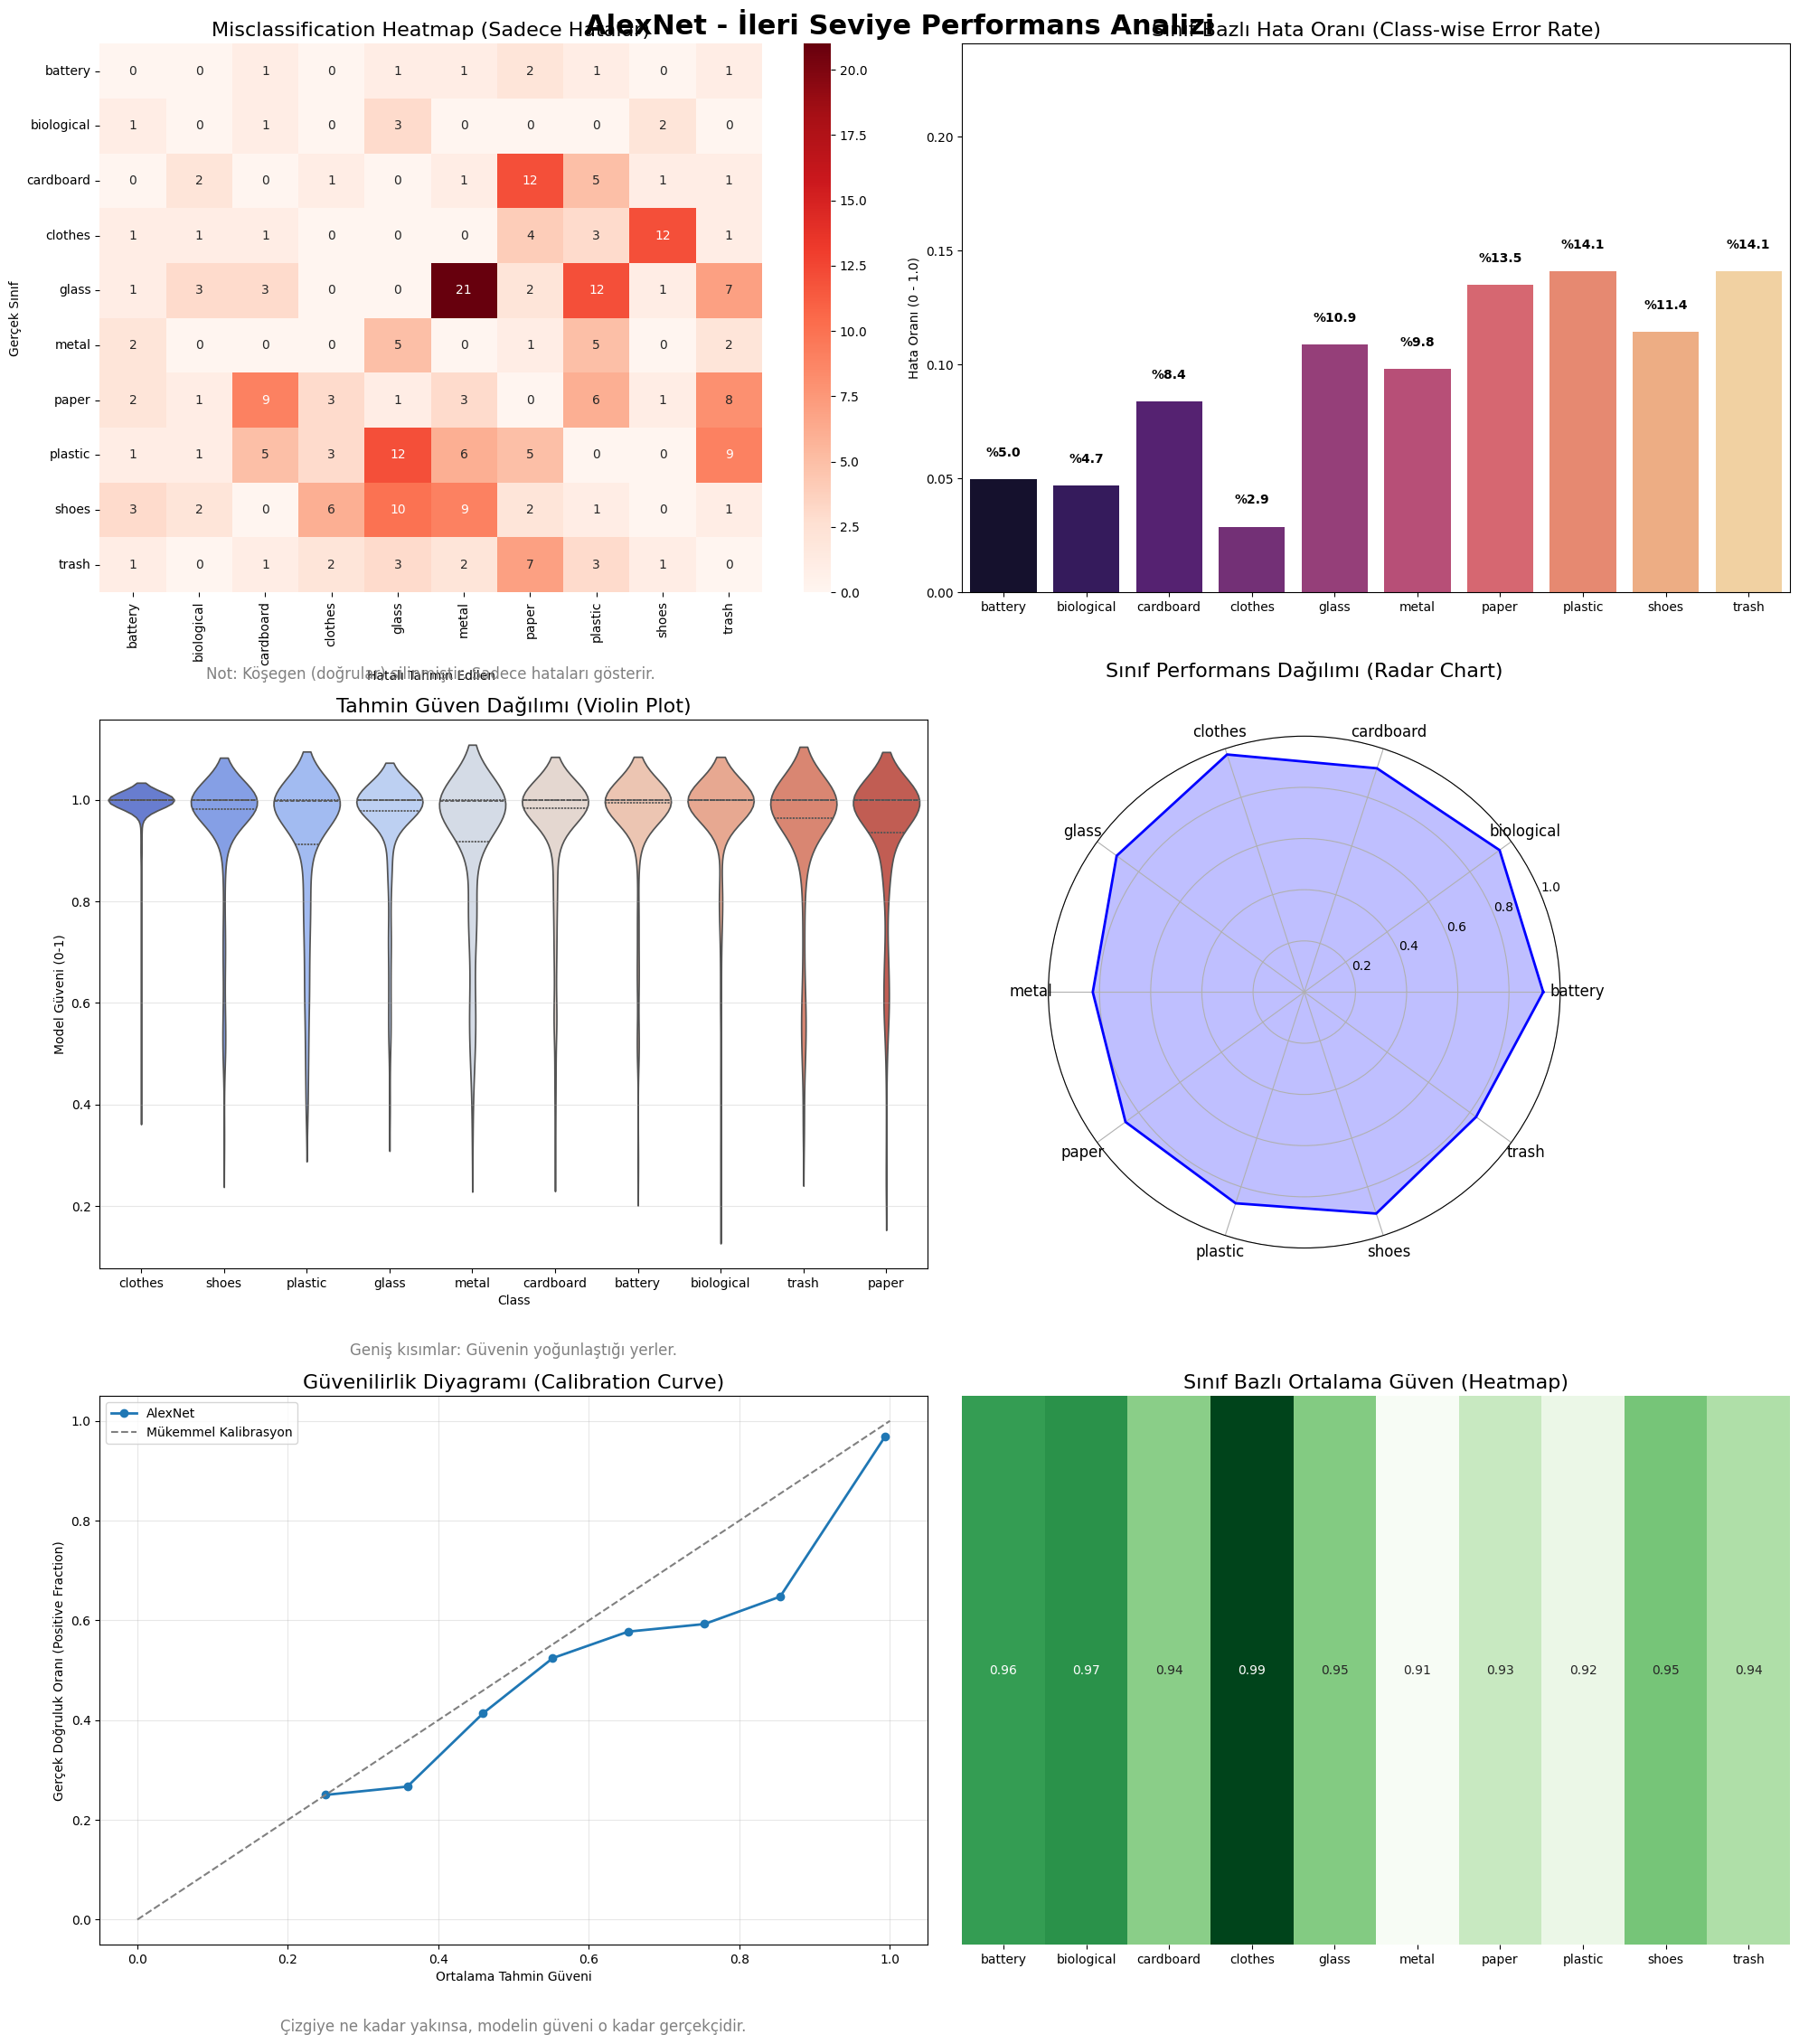

✅ İleri seviye grafikler 'AlexNet_Advanced_Visuals.png' olarak kaydedildi.


In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.calibration import calibration_curve

def advanced_supplemental_visuals(model, loader, class_names, model_name="Model"):
    """
    Standart grafiklerin dışında, tezi zenginleştirecek EKSTRA analizler:
    1. Error-Only Heatmap
    2. Class-wise Error Rate
    3. Per-Class Confidence Distribution (Violin Plot)
    4. Radar Chart (Spider Plot)
    5. Reliability Diagram
    """
    print(f"\n🚀 {model_name} İçin İleri Seviye Ek Grafikler Hazırlanıyor...")
    
    # Cihaz Algılama
    try:
        device = next(model.parameters()).device
    except:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    model.eval()
    model.to(device)
    
    y_true = []
    y_pred = []
    y_conf = [] # Güven skorları (Confidence)
    
    # Veri Toplama
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            probs = torch.nn.functional.softmax(outputs, dim=1)
            conf, preds = torch.max(probs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_conf.extend(conf.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_conf = np.array(y_conf)
    
    # Grafik Alanı: 3 Satır x 2 Sütun
    fig, axes = plt.subplots(3, 2, figsize=(20, 25))
    plt.suptitle(f"{model_name} - İleri Seviye Performans Analizi", fontsize=22, fontweight='bold', y=0.93)
    
    # =========================================================
    # 1. ERROR-ONLY HEATMAP (Sadece Hatalar)
    # =========================================================
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0) # Doğruları siliyoruz (Köşegeni sıfırla)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0, 0].set_title('Misclassification Heatmap (Sadece Hatalar)', fontsize=16)
    axes[0, 0].set_xlabel('Hatalı Tahmin Edilen')
    axes[0, 0].set_ylabel('Gerçek Sınıf')
    axes[0, 0].text(0.5, -0.15, "Not: Köşegen (doğrular) silinmiştir. Sadece hataları gösterir.", 
                    ha='center', va='center', transform=axes[0, 0].transAxes, fontsize=12, color='gray')

    # =========================================================
    # 2. CLASS-WISE ERROR RATE (Hata Oranı)
    # =========================================================
    # Error Rate = 1 - Recall (O sınıftan kaçını kaçırdık?)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    error_rates = [1 - report[c]['recall'] for c in class_names]
    
    sns.barplot(x=class_names, y=error_rates, ax=axes[0, 1], palette='magma')
    axes[0, 1].set_title('Sınıf Bazlı Hata Oranı (Class-wise Error Rate)', fontsize=16)
    axes[0, 1].set_ylabel('Hata Oranı (0 - 1.0)')
    axes[0, 1].set_ylim(0, max(error_rates) + 0.1)
    
    for i, v in enumerate(error_rates):
        axes[0, 1].text(i, v + 0.01, f"%{v*100:.1f}", ha='center', fontweight='bold')

    # =========================================================
    # 3. PER-CLASS CONFIDENCE (Violin Plot)
    # =========================================================
    # Her sınıf için modelin güven dağılımı
    df_conf = pd.DataFrame({'Class': [class_names[i] for i in y_pred], 'Confidence': y_conf})
    
    sns.violinplot(x='Class', y='Confidence', data=df_conf, ax=axes[1, 0], palette='coolwarm', inner='quartile')
    axes[1, 0].set_title('Tahmin Güven Dağılımı (Violin Plot)', fontsize=16)
    axes[1, 0].set_ylabel('Model Güveni (0-1)')
    axes[1, 0].grid(True, axis='y', alpha=0.3)
    axes[1, 0].text(0.5, -0.15, "Geniş kısımlar: Güvenin yoğunlaştığı yerler.", 
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=12, color='gray')

    # =========================================================
    # 4. RADAR CHART (Örümcek Ağı - F1 Score)
    # =========================================================
    # Radar chart Matplotlib'de biraz manuel çizilir
    ax_radar = axes[1, 1]
    # Polar koordinat sistemine geçmek için subplot yerine replace ediyoruz (Hileli yöntem)
    pos = ax_radar.get_position()
    ax_radar.remove()
    ax_radar = fig.add_axes(pos, polar=True)
    
    # Veriler
    values = [report[c]['f1-score'] for c in class_names]
    values += values[:1] # Döngüyü kapatmak için ilk değeri sona ekle
    
    angles = np.linspace(0, 2 * np.pi, len(class_names), endpoint=False).tolist()
    angles += angles[:1]
    
    ax_radar.plot(angles, values, linewidth=2, linestyle='solid', color='blue', label='F1-Score')
    ax_radar.fill(angles, values, 'blue', alpha=0.25)
    
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(class_names, size=12)
    ax_radar.set_title('Sınıf Performans Dağılımı (Radar Chart)', fontsize=16, y=1.1)
    ax_radar.set_ylim(0, 1.0)
    ax_radar.grid(True)

    # =========================================================
    # 5. RELIABILITY DIAGRAM (Kalibrasyon Eğrisi)
    # =========================================================
    # Modelin güveni ile doğruluğu arasındaki ilişki (Sadece Accuracy'yi değil, Kalibrasyonu ölçer)
    # Çok sınıflı olduğu için "Genel" (Flattened) veya "Weighted" bakılır. Basitlik için genel bakıyoruz.
    prob_true, prob_pred = calibration_curve(y_true == y_pred, y_conf, n_bins=10)
    
    axes[2, 0].plot(prob_pred, prob_true, marker='o', linewidth=2, label=model_name)
    axes[2, 0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Mükemmel Kalibrasyon')
    axes[2, 0].set_title('Güvenilirlik Diyagramı (Calibration Curve)', fontsize=16)
    axes[2, 0].set_xlabel('Ortalama Tahmin Güveni')
    axes[2, 0].set_ylabel('Gerçek Doğruluk Oranı (Positive Fraction)')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].text(0.5, -0.15, "Çizgiye ne kadar yakınsa, modelin güveni o kadar gerçekçidir.", 
                    ha='center', va='center', transform=axes[2, 0].transAxes, fontsize=12, color='gray')

    # =========================================================
    # 6. SINIF BAZLI CONFIDENCE HEATMAP
    # =========================================================
    # Hangi sınıf tahmin edildiğinde ortalama güven kaç?
    avg_conf_per_class = df_conf.groupby('Class')['Confidence'].mean().reindex(class_names)
    conf_matrix = avg_conf_per_class.values.reshape(1, -1)
    
    sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Greens', ax=axes[2, 1],
                xticklabels=class_names, yticklabels=['Ort. Güven'], cbar=False)
    axes[2, 1].set_title('Sınıf Bazlı Ortalama Güven (Heatmap)', fontsize=16)
    axes[2, 1].set_yticks([]) # Y ekseni yazısını kaldır

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{model_name}_Advanced_Visuals.png")
    plt.show()
    print(f"✅ İleri seviye grafikler '{model_name}_Advanced_Visuals.png' olarak kaydedildi.")

# --- ÇALIŞTIRMA KISMI ---

# 1. AlexNet İçin Çalıştır
if 'trained_alexnet' in globals():
    advanced_supplemental_visuals(trained_alexnet, test_dl, classes, model_name="AlexNet")
else:
    print("⚠️ 'trained_alexnet' bulunamadı.")


🚀 AlexNet İçin Sınıf Bazlı Detaylı Analiz Başlıyor...


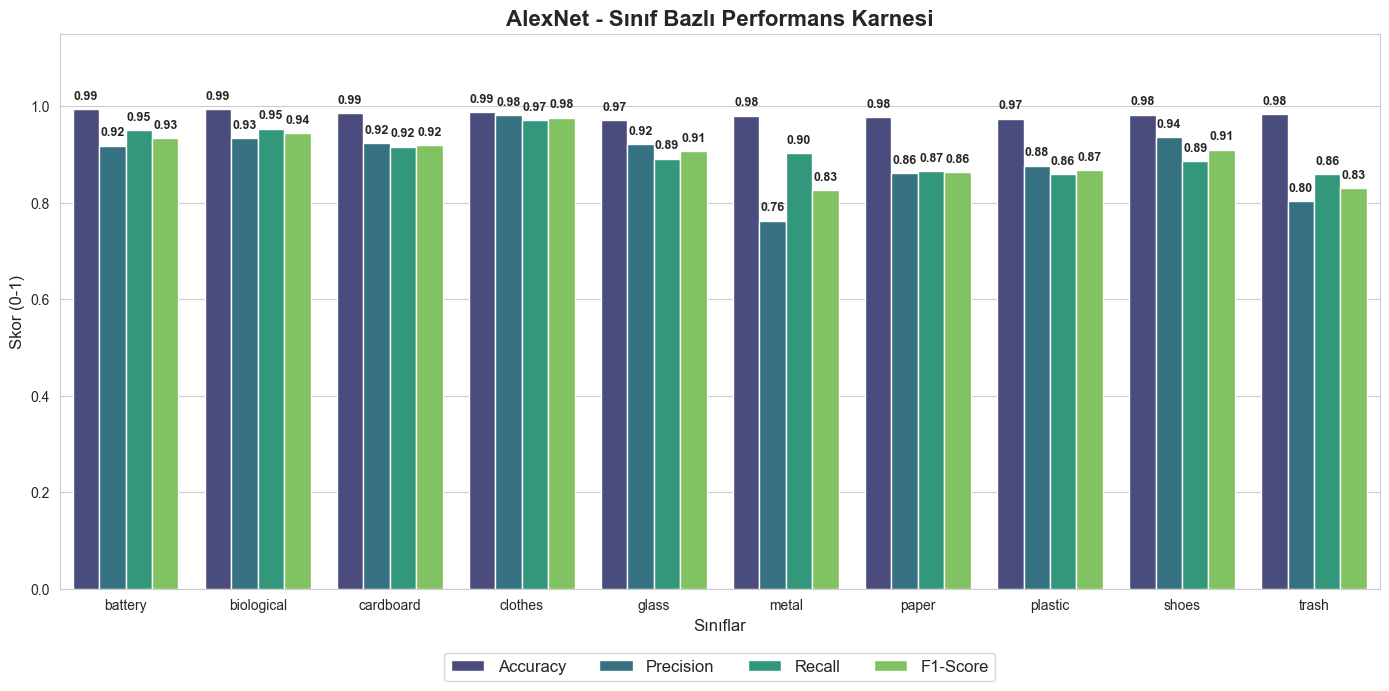

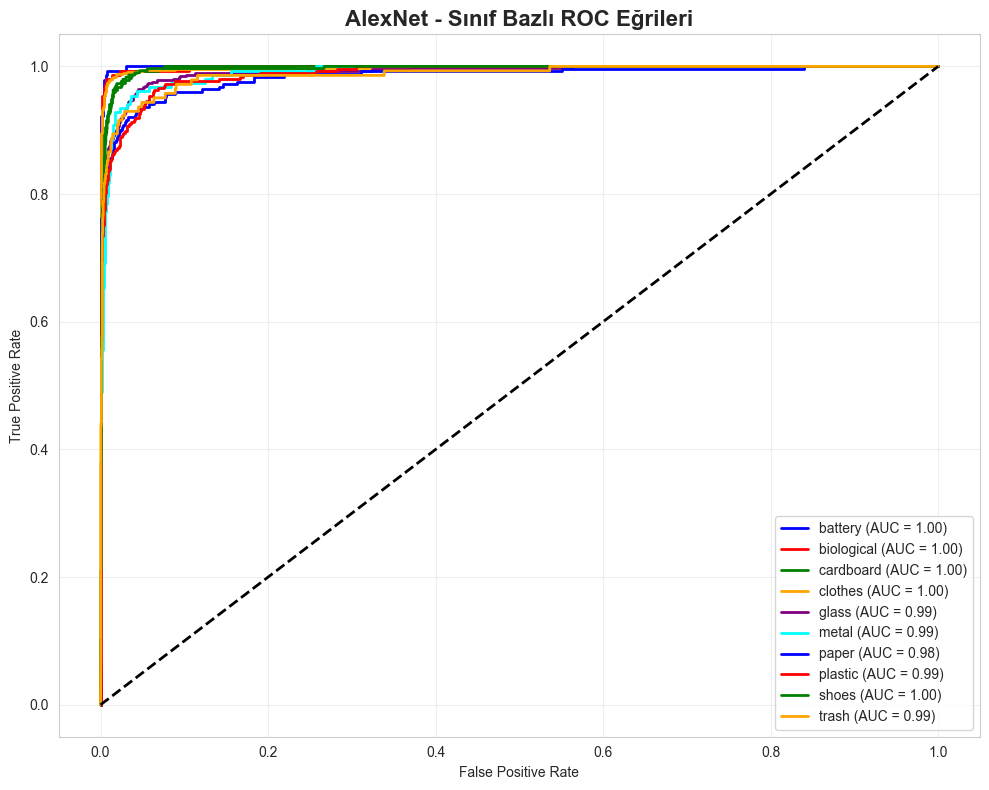

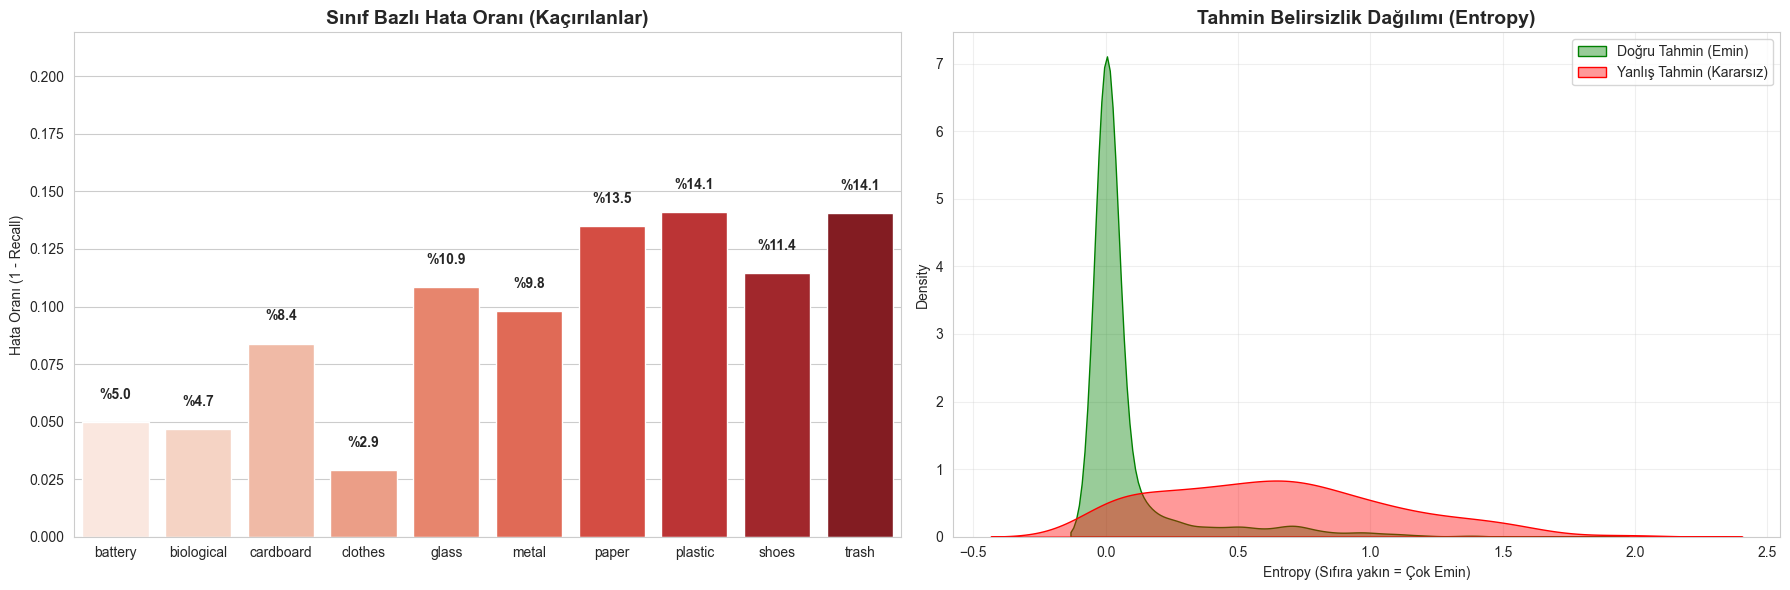

In [28]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
from itertools import cycle

def visualize_class_performance(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon her sınıf için:
    1. Precision, Recall, F1 ve Accuracy (One-vs-Rest) değerlerini hesaplar.
    2. Bunları GRUP BAR GRAFİĞİ olarak çizer.
    3. ROC Eğrilerini ekler.
    4. Prediction Entropy ve Hata Oranlarını görselleştirir.
    """
    
    print(f"\n🚀 {model_name} İçin Sınıf Bazlı Detaylı Analiz Başlıyor...")
    
    # 1. Cihaz Algılama
    try:
        device = next(model.parameters()).device
    except:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    model.eval()
    model.to(device)
    
    y_true = []
    y_pred = []
    y_probs = []
    y_entropy = []
    
    # 2. Veri Toplama
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            # Entropy: -sum(p * log(p))
            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            y_entropy.extend(entropy.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    y_entropy = np.array(y_entropy)
    
    n_classes = len(class_names)
    
    # =========================================================================
    # HESAPLAMALAR: Her Sınıf İçin Accuracy, Precision, Recall, F1
    # =========================================================================
    cm = confusion_matrix(y_true, y_pred)
    
    # Sınıf bazlı metrikleri saklayacak listeler
    class_acc = []
    class_prec = []
    class_rec = []
    class_f1 = []
    
    # Precision, Recall, F1 (Scikit-learn hazır fonksiyonu)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=range(n_classes), zero_division=0)
    
    # Per-Class Accuracy Hesaplama (One-vs-Rest Mantığı)
    # Accuracy_i = (TP_i + TN_i) / Toplam
    total_samples = np.sum(cm)
    for i in range(n_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = total_samples - (tp + fp + fn)
        
        acc = (tp + tn) / total_samples
        class_acc.append(acc)
        
    class_prec = p
    class_rec = r
    class_f1 = f
    
    # DataFrame oluştur (Grafik için)
    df_metrics = pd.DataFrame({
        'Sınıf': class_names,
        'Accuracy': class_acc,
        'Precision': class_prec,
        'Recall': class_rec,
        'F1-Score': class_f1
    })
    
    # =========================================================================
    # GRAFİK 1: SINIF BAZLI METRİKLER (GRUP BAR GRAFİĞİ)
    # =========================================================================
    # Pandas ile kolay çizim için veriyi "Melt" et (Uzun formata çevir)
    df_melted = df_metrics.melt(id_vars="Sınıf", var_name="Metrik", value_name="Skor")
    
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    # Bar Plot
    bar_plot = sns.barplot(x="Sınıf", y="Skor", hue="Metrik", data=df_melted, palette="viridis")
    
    plt.title(f"{model_name} - Sınıf Bazlı Performans Karnesi", fontsize=16, fontweight='bold')
    plt.ylim(0, 1.15) # Üstte boşluk bırak (yazılar için)
    plt.ylabel("Skor (0-1)", fontsize=12)
    plt.xlabel("Sınıflar", fontsize=12)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=12)
    
    # Çubukların üzerine değerleri yaz
    for p in bar_plot.patches:
        if p.get_height() > 0:
            bar_plot.annotate(f'{p.get_height():.2f}', 
                              (p.get_x() + p.get_width() / 2., p.get_height()), 
                              ha='center', va='bottom', fontsize=9, rotation=0, xytext=(0, 5), 
                              textcoords='offset points', fontweight='bold')
            
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # GRAFİK 2: ROC EĞRİLERİ (HER SINIF İÇİN)
    # =========================================================================
    plt.figure(figsize=(10, 8))
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])
    
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title(f"{model_name} - Sınıf Bazlı ROC Eğrileri", fontsize=16, fontweight='bold')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # GRAFİK 3: ENTROPY & ERROR RATE (HATA VE BELİRSİZLİK)
    # =========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # A) Class-wise Error Rate (Hata Oranı = 1 - Recall)
    # Yani o sınıftaki örneklerin kaçını kaçırdık?
    error_rates = 1 - df_metrics['Recall']
    
    sns.barplot(x=class_names, y=error_rates, ax=axes[0], palette="Reds")
    axes[0].set_title("Sınıf Bazlı Hata Oranı (Kaçırılanlar)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Hata Oranı (1 - Recall)")
    axes[0].set_ylim(0, max(error_rates) * 1.2 + 0.05)
    
    for i, v in enumerate(error_rates):
        axes[0].text(i, v + 0.01, f"%{v*100:.1f}", ha='center', fontweight='bold')

    # B) Prediction Entropy (Tahmin Belirsizliği)
    # Doğru ve Yanlış tahminlerin belirsizlik dağılımı
    correct_mask = y_true == y_pred
    sns.kdeplot(y_entropy[correct_mask], fill=True, color='green', label='Doğru Tahmin (Emin)', ax=axes[1], alpha=0.4)
    sns.kdeplot(y_entropy[~correct_mask], fill=True, color='red', label='Yanlış Tahmin (Kararsız)', ax=axes[1], alpha=0.4)
    
    axes[1].set_title("Tahmin Belirsizlik Dağılımı (Entropy)", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Entropy (Sıfıra yakın = Çok Emin)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



# 1. AlexNet İçin
if 'trained_alexnet' in globals():
    visualize_class_performance(trained_alexnet, test_dl, classes, model_name="AlexNet")




🚀 AlexNet İÇİN KAPSAMLI ANALİZ BAŞLIYOR...

📊 AlexNet - SINIF BAZLI DOĞRULUK (ACCURACY) TABLOSU
--------------------------------------------------
     Sınıf  Accuracy
   battery    0.9504
biological    0.9530
 cardboard    0.9161
   clothes    0.9712
     glass    0.8913
     metal    0.9020
     paper    0.8651
   plastic    0.8591
     shoes    0.8855
     trash    0.8592


🎯 AlexNet - SINIF BAZLI HASSASİYET (PRECISION) TABLOSU
--------------------------------------------------
     Sınıf  Precision
   battery     0.9178
biological     0.9342
 cardboard     0.9228
   clothes     0.9810
     glass     0.9213
     metal     0.7624
     paper     0.8617
   plastic     0.8767
     shoes     0.9359
     trash     0.8026


📢 AlexNet - SINIF BAZLI DUYARLILIK (RECALL) TABLOSU
--------------------------------------------------
     Sınıf  Recall
   battery  0.9504
biological  0.9530
 cardboard  0.9161
   clothes  0.9712
     glass  0.8913
     metal  0.9020
     paper  0.8651
   plastic  0.

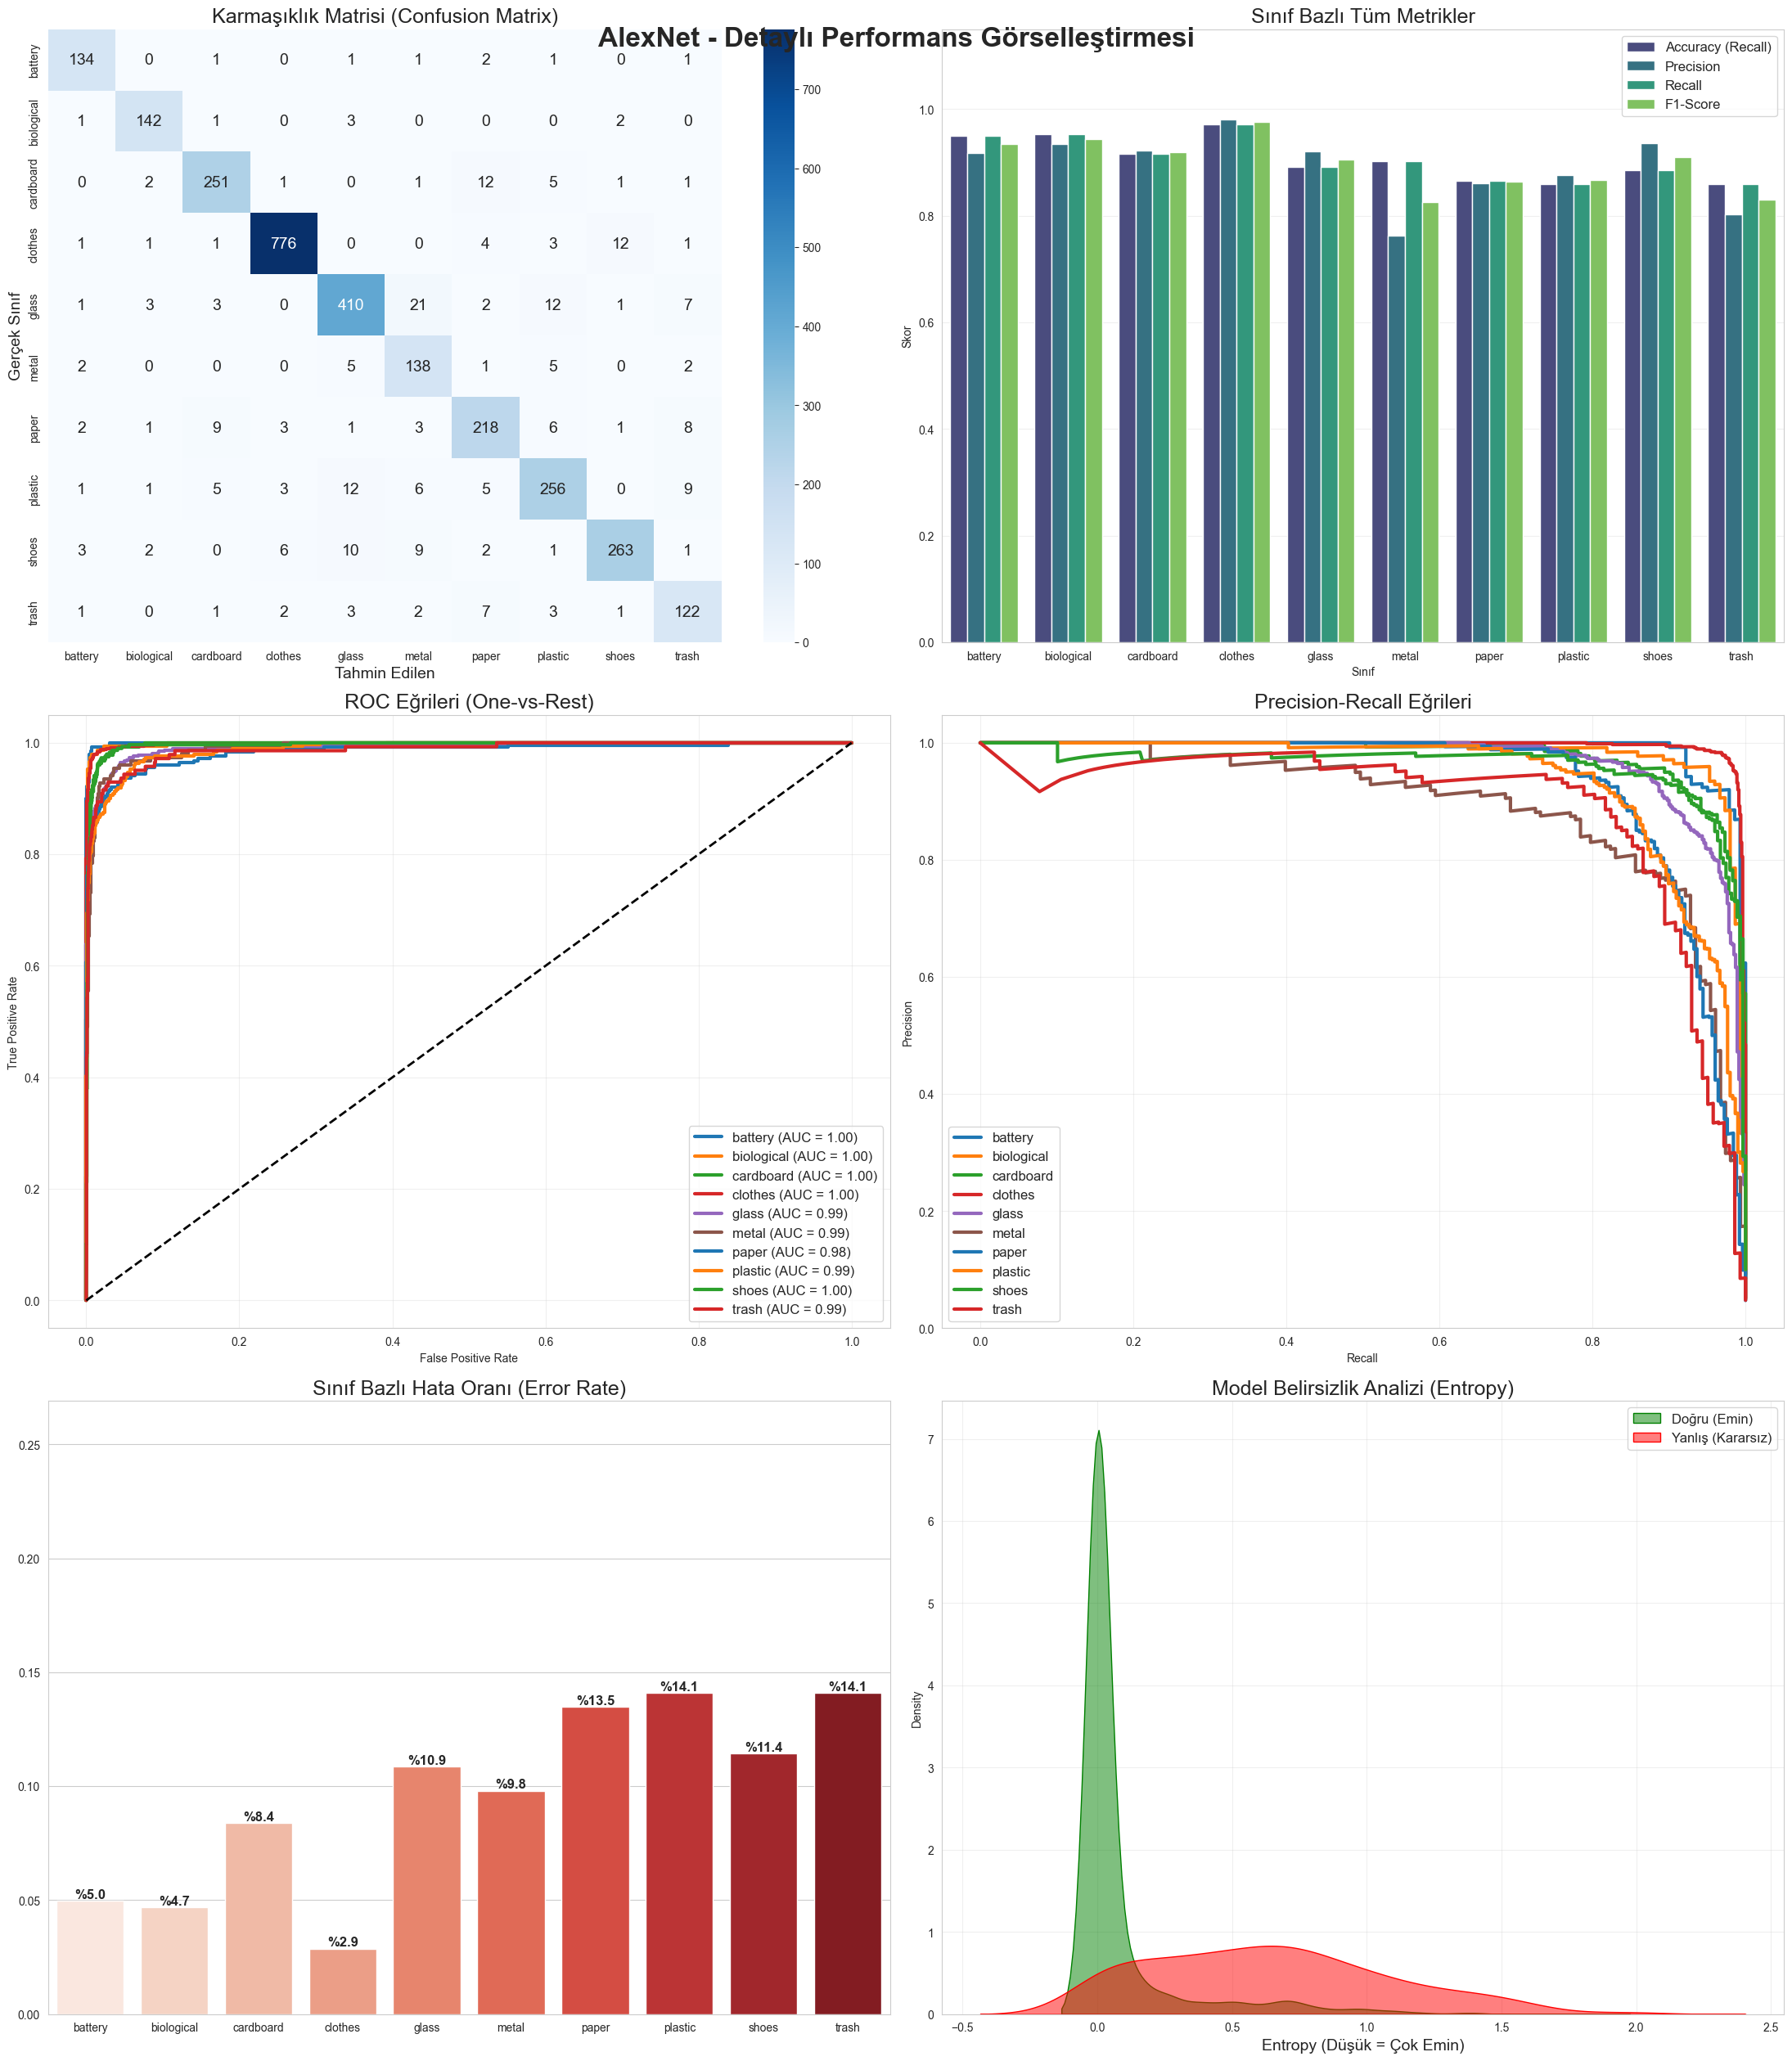


✅ Tüm işlemler tamamlandı! Grafikler 'AlexNet_Ultimate_Report.png' dosyasına kaydedildi.


In [29]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
from itertools import cycle
import warnings

# Uyarıları kapat (Temiz çıktı için)
warnings.filterwarnings('ignore')

def thesis_full_analysis(model, loader, class_names, model_name="Model"):
    """
    Bu fonksiyon:
    1. Her metrik (Acc, Prec, Rec, F1) için AYRI AYRI tablo basar.
    2. Tez/Rapor kalitesinde 6 farklı grafik çizer.
    """
    print(f"\n🚀 {model_name} İÇİN KAPSAMLI ANALİZ BAŞLIYOR...\n")
    
    # --- 1. Cihaz ve Veri Hazırlığı ---
    try:
        device = next(model.parameters()).device
    except:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    model.eval()
    model.to(device)
    
    y_true = []
    y_pred = []
    y_probs = []
    y_entropy = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            
            # Entropy (Belirsizlik)
            entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            y_entropy.extend(entropy.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    y_entropy = np.array(y_entropy)
    
    # --- 2. AYRI AYRI TABLOLARIN OLUŞTURULMASI ---
    
    # Scikit-learn raporunu al
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Verileri çek
    data = {
        "Sınıf": class_names,
        "Accuracy (Recall)": [report[c]['recall'] for c in class_names], # Sınıf bazlı accuracy = Recall
        "Precision": [report[c]['precision'] for c in class_names],
        "Recall": [report[c]['recall'] for c in class_names],
        "F1-Score": [report[c]['f1-score'] for c in class_names]
    }
    
    # TABLO 1: SINIF BAZLI ACCURACY TABLOSU
    df_acc = pd.DataFrame({"Sınıf": data["Sınıf"], "Accuracy": data["Accuracy (Recall)"]})
    print(f"📊 {model_name} - SINIF BAZLI DOĞRULUK (ACCURACY) TABLOSU")
    print("-" * 50)
    print(df_acc.round(4).to_string(index=False))
    print("\n")

    # TABLO 2: SINIF BAZLI PRECISION TABLOSU
    df_prec = pd.DataFrame({"Sınıf": data["Sınıf"], "Precision": data["Precision"]})
    print(f"🎯 {model_name} - SINIF BAZLI HASSASİYET (PRECISION) TABLOSU")
    print("-" * 50)
    print(df_prec.round(4).to_string(index=False))
    print("\n")

    # TABLO 3: SINIF BAZLI RECALL TABLOSU
    df_rec = pd.DataFrame({"Sınıf": data["Sınıf"], "Recall": data["Recall"]})
    print(f"📢 {model_name} - SINIF BAZLI DUYARLILIK (RECALL) TABLOSU")
    print("-" * 50)
    print(df_rec.round(4).to_string(index=False))
    print("\n")

    # TABLO 4: SINIF BAZLI F1-SCORE TABLOSU
    df_f1 = pd.DataFrame({"Sınıf": data["Sınıf"], "F1-Score": data["F1-Score"]})
    print(f"⚖️ {model_name} - SINIF BAZLI F1 SKORU TABLOSU")
    print("-" * 50)
    print(df_f1.round(4).to_string(index=False))
    print("\n" + "="*60 + "\n")
    
    # Tabloları Kaydet (CSV)
    df_acc.to_csv(f"{model_name}_Table_Accuracy.csv", index=False)
    df_prec.to_csv(f"{model_name}_Table_Precision.csv", index=False)
    df_rec.to_csv(f"{model_name}_Table_Recall.csv", index=False)
    df_f1.to_csv(f"{model_name}_Table_F1.csv", index=False)

    # --- 3. EKSİKSİZ VE DÜZGÜN GRAFİKLER ---
    
    # Grafik Alanı: 3 Satır x 2 Sütun (Büyük Boyut)
    fig, axes = plt.subplots(3, 2, figsize=(22, 28))
    plt.suptitle(f"{model_name} - Detaylı Performans Görselleştirmesi", fontsize=24, fontweight='bold', y=0.92)
    
    # Renk Paletleri
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    
    # --- G1: CONFUSION MATRIX ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
    axes[0, 0].set_title('Karmaşıklık Matrisi (Confusion Matrix)', fontsize=18)
    axes[0, 0].set_xlabel('Tahmin Edilen', fontsize=14)
    axes[0, 0].set_ylabel('Gerçek Sınıf', fontsize=14)

    # --- G2: SINIF BAZLI METRİKLER (GRUP BAR) ---
    # Accuracy, Precision, Recall, F1 yan yana
    df_full = pd.DataFrame(data)
    df_melt = df_full.melt(id_vars="Sınıf", var_name="Metrik", value_name="Skor")
    
    sns.barplot(x="Sınıf", y="Skor", hue="Metrik", data=df_melt, ax=axes[0, 1], palette="viridis")
    axes[0, 1].set_title('Sınıf Bazlı Tüm Metrikler', fontsize=18)
    axes[0, 1].set_ylim(0, 1.15)
    axes[0, 1].legend(loc='upper right', fontsize=12)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # --- G3: ROC EĞRİLERİ ---
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1, 0].plot(fpr, tpr, color=color, lw=3, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[1, 0].set_title('ROC Eğrileri (One-vs-Rest)', fontsize=18)
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(loc="lower right", fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # --- G4: PRECISION-RECALL EĞRİLERİ ---
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    for i, color in zip(range(len(class_names)), colors):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        axes[1, 1].plot(recall, precision, color=color, lw=3, label=f'{class_names[i]}')
        
    axes[1, 1].set_title('Precision-Recall Eğrileri', fontsize=18)
    axes[1, 1].set_xlabel('Recall')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend(loc="lower left", fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

    # --- G5: ERROR RATE (HATA ORANI) ---
    error_rates = [1 - r for r in data["Recall"]]
    sns.barplot(x=class_names, y=error_rates, ax=axes[2, 0], palette="Reds")
    axes[2, 0].set_title('Sınıf Bazlı Hata Oranı (Error Rate)', fontsize=18)
    axes[2, 0].set_ylim(0, max(error_rates) * 1.2 + 0.1)
    # Değerleri yaz
    for p in axes[2, 0].patches:
        axes[2, 0].annotate(f'%{p.get_height()*100:.1f}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='bottom', fontsize=12, fontweight='bold')

    # --- G6: PREDICTION ENTROPY (BELİRSİZLİK) ---
    correct_mask = y_true == y_pred
    sns.kdeplot(y_entropy[correct_mask], fill=True, color='green', label='Doğru (Emin)', ax=axes[2, 1], alpha=0.5)
    sns.kdeplot(y_entropy[~correct_mask], fill=True, color='red', label='Yanlış (Kararsız)', ax=axes[2, 1], alpha=0.5)
    axes[2, 1].set_title('Model Belirsizlik Analizi (Entropy)', fontsize=18)
    axes[2, 1].set_xlabel('Entropy (Düşük = Çok Emin)', fontsize=14)
    axes[2, 1].legend(fontsize=12)
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{model_name}_Ultimate_Report.png")
    plt.show()
    print(f"\n✅ Tüm işlemler tamamlandı! Grafikler '{model_name}_Ultimate_Report.png' dosyasına kaydedildi.")



if 'trained_alexnet' in globals():
    thesis_full_analysis(trained_alexnet, test_dl, classes, model_name="AlexNet")

